# Module 07 Lab - Better Model Evaluation
**Objective:** To move beyond simple accuracy and learn how to use more sophisticated and reliable evaluation techniques, including the confusion matrix, precision, recall, and cross-validation.

**In this lab, you will write the code to generate and interpret these advanced evaluation metrics.**

## Part 1: Setup and Model Training
Let's first train a model so we have something to evaluate. We will use the Titanic dataset again to predict survival.

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load and prepare data
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Age'].fillna(df['Age'].median(), inplace=True)

features = ['Age', 'Pclass', 'Sex', 'Fare']
target = 'Survived'

X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/tmp/ipykernel_5239/908244282.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


## Part 2: The Confusion Matrix
**Concept:** A confusion matrix gives you a more detailed breakdown of a model's performance than accuracy alone. It's a table that shows you where your model got things right and where it got them wrong.It has four quadrants:
*   **True Positives (TP):** Correctly predicted positive (e.g., predicted survival, and they did survive).
*   **True Negatives (TN):** Correctly predicted negative (e.g., predicted did not survive, and they did not).
*   **False Positives (FP):** Incorrectly predicted positive (e.g., predicted survival, but they did not). Also called a "Type I Error".
*   **False Negatives (FN):** Incorrectly predicted negative (e.g., predicted did not survive, but they did). Also called a "Type II Error".

### Task 1: Generate and Plot a Confusion Matrix
**Your Task:** Use `confusion_matrix` from `sklearn.metrics` to calculate the matrix and `seaborn.heatmap` to visualize it.

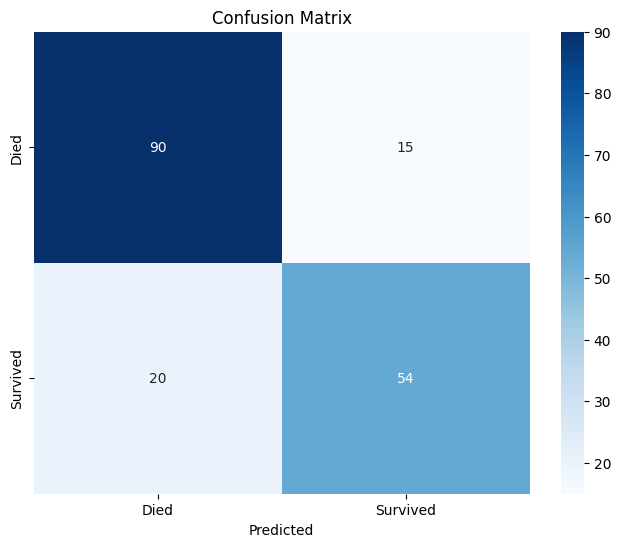

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# --- ENTER YOUR CODE HERE ---
# 1. Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Create a heatmap to visualize it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted')# plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Part 3: Precision, Recall, and F1-Score
**Concept:** From the confusion matrix, we can calculate more nuanced metrics:
*   **Precision:** Of all the times the model predicted **positive**, how often was it correct?
*   Formula: `TP / (TP + FP)`    
*   *Use Case:* When the cost of a **False Positive** is high. (e.g., a spam filter; you don't want to incorrectly mark an important email as spam).
*   **Recall (Sensitivity):** Of all the actual **positives**, how many did the model correctly identify?    
*   Formula: `TP / (TP + FN)`    
*   *Use Case:* When the cost of a **False Negative** is high. (e.g., a medical test for a serious disease; you don't want to miss a real case).
*   **F1-Score:** The harmonic mean of Precision and Recall. It provides a single score that balances both.

### Task 2: Generate a Classification Report**Your Task:** Use `classification_report` from `sklearn.metrics` to get a summary of these metrics for each class.

In [6]:
from sklearn.metrics import classification_report
# --- ENTER YOUR CODE HERE ---
# 1. Generate and print the classification report
report = classification_report(y_test, y_pred, target_names=["Died", "Survived"])
print(report)

              precision    recall  f1-score   support

        Died       0.82      0.86      0.84       105
    Survived       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



## Part 4: Cross-Validation
**Concept:** A single train-test split can be lucky or unlucky. What if, by chance, all the "easy" examples ended up in our test set? Our accuracy score would be misleadingly high.

**Cross-Validation (CV)** solves this. It splits the data into multiple "folds" (e.g., 5 or 10). It then trains and evaluates the model multiple times, using a different fold as the test set each time. The final score is the average of the scores from all folds.This gives a much more robust and reliable estimate of the model's true performance.

### Task 3: Perform Cross-Validation
**Your Task:** Use `cross_val_score` from `sklearn.model_selection` to perform 5-fold cross-validation on your model.

In [7]:
from sklearn.model_selection import cross_val_score
# --- ENTER YOUR CODE HERE ---
# 1. Perform 5-fold cross-validation
#    Note: We use the *entire* dataset (X, y) here, as cross_val_score handles the splitting internally.
cv_scores = cross_val_score(model, X, y, cv=5)

# 2. Print the scores for each fold and the average score
print(f"Scores for each fold: {cv_scores}")
print(f"Average CV Score: {cv_scores.mean():.2%}")
print(f"Standard Deviation of CV Scores: {cv_scores.std():.4f}")

Scores for each fold: [0.7877095  0.78089888 0.78651685 0.7752809  0.80337079]
Average CV Score: 78.68%
Standard Deviation of CV Scores: 0.0094


## 📝 Knowledge Check
**Instructions:** Answer the following questions in this markdown cell.
1.  **Describe a real-world scenario where you would care more about a model's Precision than its Recall.**

In a real-world scenario, a spam-email filter is useful in this situation because precision is more important than recall. When the model identifies an email as spam, we want it to be correct because a false positive could cause an important legitimate email to be placed in the spam folder.

---

2.  **Describe a real-world scenario where you would care more about a model's Recall than its Precision.**

A medical screening model can be used as a real-life scenario because the recall is more important than precision. It is important to identify as many patients with the disease as possible because a false negative could cause a real case to be missed. False positives can be checked through additional testing.


---

3.  **Why is a cross-validation score generally more trustworthy than a score from a single train-test split?**

A cross-validation score is generally more trustworthy because it evaluates the model using several different training and testing splits, which reduces the effect of a lucky or unlucky single split and provides a more stable estimate of how the model will perform on new data.

---
